# 03. 라벨링 + 분류 모델 학습 (Labeling & Modeling)

이 노트북에서는:
1. 임상 기준 우선순위 규칙으로 건강관리 유형 라벨 부여
2. Random Forest 분류 모델 학습
3. 유형별 프로파일 시각화

## 설계 배경

초기에는 K-Means 비지도학습으로 군집을 먼저 만들고 Random Forest를 학습하는 방식을 시도했으나,  
다음 문제가 발견되어 룰 기반 라벨링으로 전환했습니다:
- 음주 변수에 군집이 과도하게 지배되어 BMI 정상인 군집이 체중관리형으로 매핑됨
- Silhouette Score 0.21로 군집 경계가 불분명함
- 사전 정의된 임상 유형(6종)이 있는 상황에서 비지도학습 사용은 설계 모순

In [1]:
import sys
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

## 1. 전처리된 데이터 준비

In [2]:
from src.preprocessing import run_full_preprocessing

df = run_full_preprocessing('../data/raw/2024_국민건강보험공단_건강검진정보.CSV')
print(f'준비 완료: {df.shape[0]:,}행')

[load_raw_data] 원본 데이터 크기: 1,000,000행 × 33열
[select_model_columns] 선택된 컬럼: ['gender', 'age_group', 'region_code', 'height_cm', 'weight_kg', 'waist_cm', 'systolic_bp', 'diastolic_bp', 'fasting_glucose', 'smoking_status', 'drinking']
[handle_missing_values] 필수값 결측 제거: 1,000,000 → 1,000,000행
[handle_missing_values] 처리 후 남은 결측치: 0개
[remove_outliers] 이상치 제거: 1,000,000 → 999,777행
[engineer_features] 파생변수 생성 완료: bmi, bmi_category, age_label, hypertension_flag, hyperglycemia_flag, abdominal_obesity_flag, obesity_flag, metabolic_risk_count

✅ 전처리 완료: 최종 999,777행 × 19열
준비 완료: 999,777행


## 2. 표준화 + 룰 기반 라벨링

In [3]:
# 모델 학습 변수 (총콜레스테롤 제외 - 결측 ~66%)
from src.modeling import MODEL_FEATURES
from sklearn.preprocessing import StandardScaler

X = df[MODEL_FEATURES].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'표준화 완료: {X_scaled.shape}')

표준화 완료: (999777, 7)


In [4]:
# 임상 기준 우선순위 규칙으로 라벨 부여
from src.modeling import assign_labels_by_rule, HEALTH_TYPE_MAPPING

y_labels = assign_labels_by_rule(df)


[assign_labels_by_rule] 유형별 라벨 분포:
  - blood_pressure      : 248,769건 (24.9%)
  - metabolic           : 239,626건 (24.0%)
  - lifestyle           : 191,228건 (19.1%)
  - blood_sugar         : 135,400건 (13.5%)
  - weight              : 102,758건 (10.3%)
  - basic               : 81,996건 (8.2%)


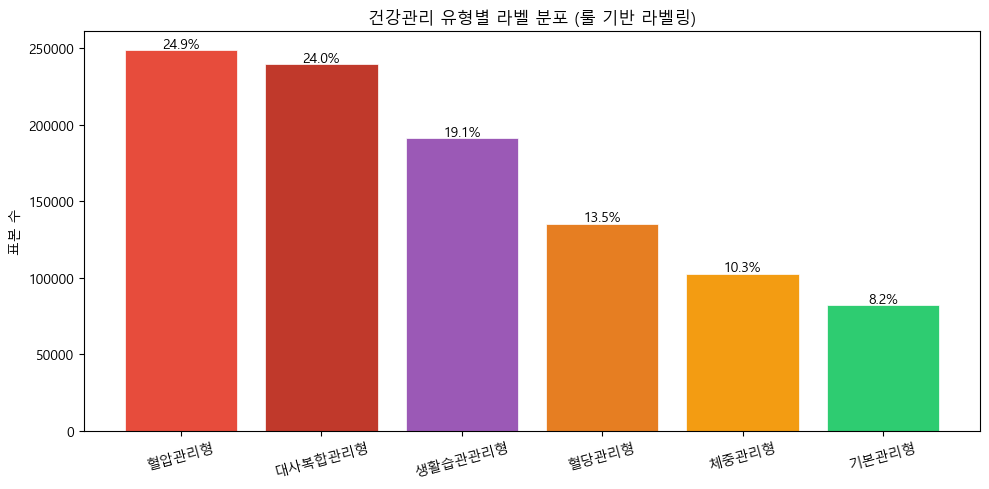

In [5]:
# 라벨 분포 시각화
import os
os.makedirs('../reports/figures/labeling', exist_ok=True)  # 폴더 없으면 자동 생성
import matplotlib.pyplot as plt
import numpy as np

label_series = pd.Series(y_labels)
counts = label_series.value_counts()
colors = [HEALTH_TYPE_MAPPING[lbl]['color'] for lbl in counts.index]
names  = [HEALTH_TYPE_MAPPING[lbl]['name']  for lbl in counts.index]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(names, counts.values, color=colors, edgecolor='white', linewidth=0.5)
ax.set_ylabel('표본 수')
ax.set_title('건강관리 유형별 라벨 분포 (룰 기반 라벨링)')

for bar, cnt in zip(bars, counts.values):
    pct = cnt / len(y_labels) * 100
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1500,
            f'{pct:.1f}%', ha='center', fontsize=10)

plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../reports/figures/labeling/label_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

**라벨 분포 확인 포인트**:
- 기본관리형이 가장 적게 나와야 정상 (모든 기준에 해당 안 되는 경우)
- 혈압관리형 비율이 높은 것은 한국 성인의 혈압 관리 필요 인구가 많다는 데이터 특성 반영
- 룰의 우선순위 구조상 하나의 유형에만 배정되므로 합계 = 100%

## 3. 전체 학습 파이프라인 실행

In [ ]:
# 전체 학습은 src/modeling.py의 run_full_training()으로 한 번에
from src.modeling import run_full_training

result = run_full_training(
    '../data/raw/2024_국민건강보험공단_건강검진정보.CSV',
    processed_dir='../data/processed',
    model_dir='../model',
)
print()
print(f"Overall Accuracy: {result['metrics']['overall_accuracy']:.4f}")
print(f"Macro F1:         {result['metrics']['macro_f1']:.4f}")
print(f"Weighted F1:      {result['metrics']['weighted_f1']:.4f}")

Step 1: 전처리
[load_raw_data] 원본 데이터 크기: 1,000,000행 × 33열
[select_model_columns] 선택된 컬럼: ['gender', 'age_group', 'region_code', 'height_cm', 'weight_kg', 'waist_cm', 'systolic_bp', 'diastolic_bp', 'fasting_glucose', 'smoking_status', 'drinking']
[handle_missing_values] 필수값 결측 제거: 1,000,000 → 1,000,000행
[handle_missing_values] 처리 후 남은 결측치: 0개
[remove_outliers] 이상치 제거: 1,000,000 → 999,777행
[engineer_features] 파생변수 생성 완료: bmi, bmi_category, age_label, hypertension_flag, hyperglycemia_flag, abdominal_obesity_flag, obesity_flag, metabolic_risk_count

✅ 전처리 완료: 최종 999,777행 × 19열

Step 2: 표준화
[fit_and_scale_features] 표준화 완료: (999777, 7)

Step 3: 룰 기반 라벨링

[assign_labels_by_rule] 유형별 라벨 분포:
  - blood_pressure      : 248,769건 (24.9%)
  - metabolic           : 239,626건 (24.0%)
  - lifestyle           : 191,228건 (19.1%)
  - blood_sugar         : 135,400건 (13.5%)
  - weight              : 102,758건 (10.3%)
  - basic               : 81,996건 (8.2%)

Step 4: Random Forest 분류 학습

[train_classifier] 데이터 분

## 4. 유형별 프로파일 시각화

In [7]:
profile = pd.read_csv('../data/processed/cluster_profile.csv', encoding='utf-8-sig')
profile

,health_type,health_type_name,color,n,bmi_mean,sbp_mean,dbp_mean,fbg_mean,waist_mean,smoking_current_rate,drinking_rate,metabolic_risk_mean
0,basic,기본관리형,#2ECC71,81996,21.01,111.78,67.48,88.92,72.39,0.00,0.00,0.00
1,blood_pressure,혈압관리형,#E74C3C,248769,22.84,133.19,82.58,99.56,78.64,0.19,0.63,1.55
2,blood_sugar,혈당관리형,#E67E22,135400,22.96,114.86,69.48,114.75,78.84,0.19,0.63,1.28
3,lifestyle,생활습관관리형,#9B59B6,191228,21.24,111.16,67.83,88.85,73.14,0.18,0.97,0.00
4,metabolic,대사복합관리형,#C0392B,239626,28.62,132.37,81.61,112.93,93.48,0.23,0.67,3.36
5,weight,체중관리형,#F39C12,102758,27.11,115.63,70.03,90.45,87.40,0.19,0.68,1.41


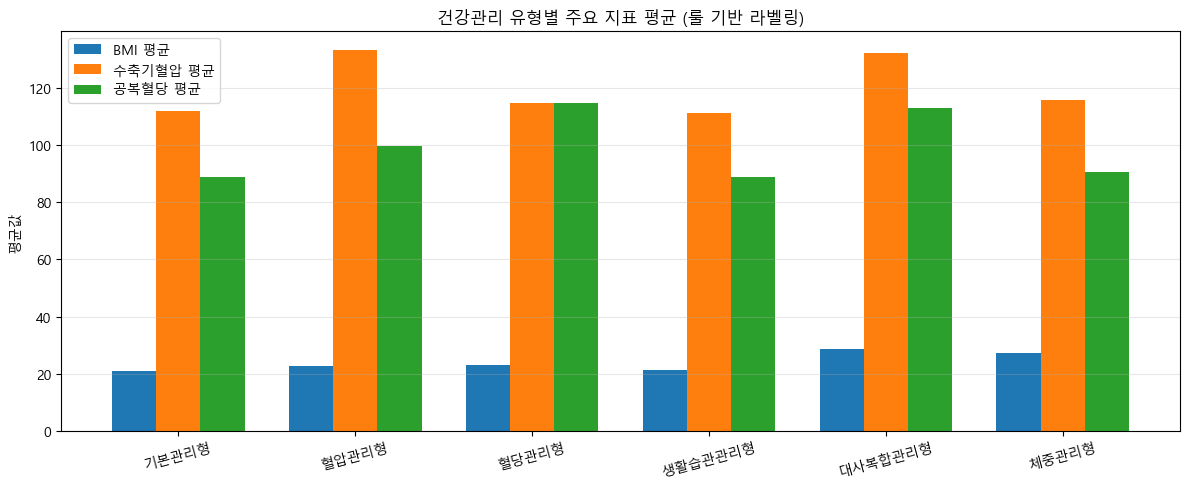

In [8]:
# 각 유형의 평균 수치 막대 그래프
fig, ax = plt.subplots(figsize=(12, 5))
metrics_to_plot = ['bmi_mean', 'sbp_mean', 'fbg_mean']
labels_plot = ['BMI 평균', '수축기혈압 평균', '공복혈당 평균']
x = np.arange(len(profile))
width = 0.25

for i, (m, lbl) in enumerate(zip(metrics_to_plot, labels_plot)):
    ax.bar(x + i * width, profile[m], width, label=lbl)

ax.set_xticks(x + width)
ax.set_xticklabels(profile['health_type_name'], rotation=15)
ax.set_ylabel('평균값')
ax.set_title('건강관리 유형별 주요 지표 평균 (룰 기반 라벨링)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/labeling/profile_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# 임상 일치성 검증: 유형별 평균이 기준값과 방향이 맞는지 확인
print('=== 임상 일치성 검증 ===')
checks = {
    'blood_pressure': ('sbp_mean', '>=', 130),
    'blood_sugar':    ('fbg_mean', '>=', 100),
    'weight':         ('bmi_mean', '>=', 25),
    'metabolic':      ('metabolic_risk_mean', '>=', 3),
}

for health_type, (col, op, threshold) in checks.items():
    row = profile[profile['health_type'] == health_type]
    if len(row) == 0:
        continue
    val = row[col].values[0]
    passed = val >= threshold
    name = row['health_type_name'].values[0]
    status = '✅' if passed else '❌'
    print(f'  {status} {name}: {col} = {val:.1f} (기준: {op} {threshold})')

=== 임상 일치성 검증 ===
  ✅ 혈압관리형: sbp_mean = 133.2 (기준: >= 130)
  ✅ 혈당관리형: fbg_mean = 114.8 (기준: >= 100)
  ✅ 체중관리형: bmi_mean = 27.1 (기준: >= 25)
  ✅ 대사복합관리형: metabolic_risk_mean = 3.4 (기준: >= 3)


## 결론

- 룰 기반 라벨링으로 6개 유형이 임상 기준에 맞게 명확히 구분됨
- 각 유형의 평균 수치가 해당 유형의 분류 기준 방향과 일치함 (임상 일치성 확인)
- Test Accuracy 약 0.99 (룰의 명확한 경계를 Random Forest가 잘 학습한 결과)
- K-Means 방식 대비 유형별 평균 수치가 임상적으로 훨씬 자연스러워짐
- 다음 단계: 04_model_evaluation.ipynb에서 상세 성능 평가